In [14]:
def plot_metric_comparison(metric_column, metric_label, print_title):
    """
    Plot and print comparison for a given metric across all dataset series.
    
    Parameters:
    - metric_column: Column name in the dataframe (e.g., 'Construction_time_ms')
    - metric_label: Label for y-axis (e.g., 'Construction Time (ms)')
    - print_title: Title for the printed comparison table
    """
    # Create three subplots for acl1, ipc1, fw1
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, series in enumerate(dataset_series):
        ax = axes[idx]
        
        # Filter data for this series
        series_data = combined_df[combined_df['Dataset'].str.startswith(series)].copy()
        series_data['Size'] = series_data['Dataset'].apply(extract_size)
        
        # Plot lines for each method
        for method in methods:
            method_data = series_data[series_data['Class'] == method].sort_values('Size')
            
            if not method_data.empty:
                # For HybridTSS, plot both Original and Improved
                if method == 'HybridTSS':
                    original = method_data[method_data['Method'] == 'Original']
                    if not original.empty:
                        ax.plot(original['Size'], original[metric_column], 
                               marker=markers[method], linewidth=2, label=f'{method} (Original)',
                               color=colors[method], linestyle='--', markersize=8)
                    
                    # Improved HybridTSS - in red
                    improved = method_data[method_data['Method'] == 'Improved']
                    if not improved.empty:
                        ax.plot(improved['Size'], improved[metric_column], 
                               marker=markers[method], linewidth=2.5, label=f'{method} (Improved)',
                               color='red', linestyle='-', markersize=8)
                else:
                    # For PSTSS and CutTSS, only show improved with original colors
                    improved = method_data[method_data['Method'] == 'Improved']
                    if not improved.empty:
                        ax.plot(improved['Size'], improved[metric_column], 
                               marker=markers[method], linewidth=2.5, label=f'{method}',
                               color=colors[method], linestyle='-', markersize=8)
        
        # Customize each subplot
        ax.set_xlabel('Dataset Size', fontsize=11, fontweight='bold')
        ax.set_ylabel(metric_label, fontsize=11, fontweight='bold')
        ax.set_title(f'{series.upper()} Dataset Series', fontsize=12, fontweight='bold')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9, loc='best')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed comparison table
    print(f"\n{print_title}:")
    print("="*120)
    for series in dataset_series:
        print(f"\n{series.upper()} Series:")
        print("-"*120)
        
        series_data = combined_df[combined_df['Dataset'].str.startswith(series)]
        
        # Create comparison for each dataset
        for method in methods:
            method_data = series_data[series_data['Class'] == method]
            
            if not method_data.empty:
                print(f"\n{method}:")
                datasets_list = sorted(method_data['Dataset'].unique())
                for dataset in datasets_list:
                    dataset_rows = method_data[method_data['Dataset'] == dataset]
                    
                    if method == 'HybridTSS':
                        # Show both Original and Improved
                        orig = dataset_rows[dataset_rows['Method'] == 'Original'][metric_column].values
                        impr = dataset_rows[dataset_rows['Method'] == 'Improved'][metric_column].values
                        
                        if len(orig) > 0 and len(impr) > 0:
                            improvement = ((orig[0] - impr[0]) / orig[0] * 100) if orig[0] > 0 else 0
                            print(f"  {dataset:12s} | Original: {orig[0]:10.4f} | Improved: {impr[0]:10.4f} | Improvement: {improvement:6.2f}%")
                    else:
                        # Show only Improved for PSTSS and CutTSS
                        impr = dataset_rows[dataset_rows['Method'] == 'Improved'][metric_column].values
                        if len(impr) > 0:
                            print(f"  {dataset:12s} | {impr[0]:10.4f}")

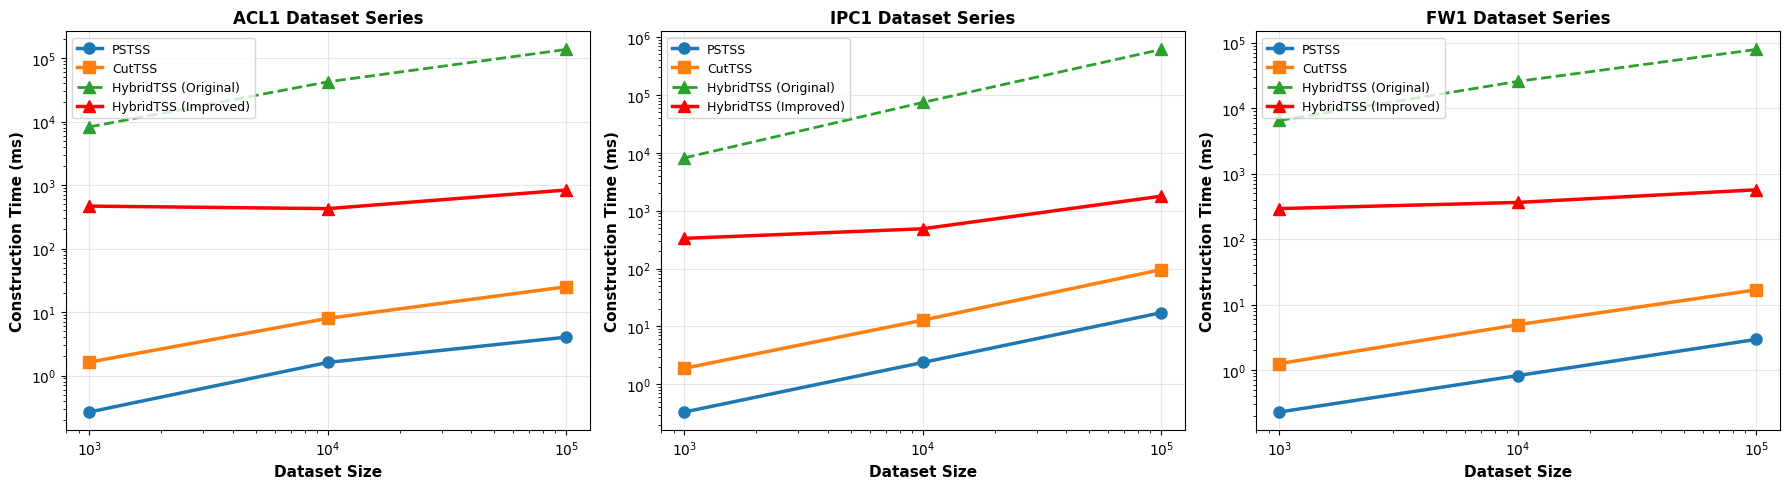


Construction Time Comparison (ms):

ACL1 Series:
------------------------------------------------------------------------------------------------------------------------

PSTSS:
  acl1_100k    |     4.0201
  acl1_10k     |     1.6096
  acl1_1k      |     0.2665

CutTSS:
  acl1_100k    |    24.9805
  acl1_10k     |     7.9484
  acl1_1k      |     1.6277

HybridTSS:
  acl1_100k    | Original: 136490.0000 | Improved:   834.5690 | Improvement:  99.39%
  acl1_10k     | Original: 42235.9000 | Improved:   425.0820 | Improvement:  98.99%
  acl1_1k      | Original:  8238.2000 | Improved:   465.7890 | Improvement:  94.35%

IPC1 Series:
------------------------------------------------------------------------------------------------------------------------

PSTSS:
  ipc1_100k    |    17.2637
  ipc1_10k     |     2.3856
  ipc1_1k      |     0.3323

CutTSS:
  ipc1_100k    |    95.8049
  ipc1_10k     |    12.8317
  ipc1_1k      |     1.8944

HybridTSS:
  ipc1_100k    | Original: 610225.0000 | Improv

In [19]:
plot_metric_comparison('Construction_time_ms', 'Construction Time (ms)', 'Construction Time Comparison (ms)')

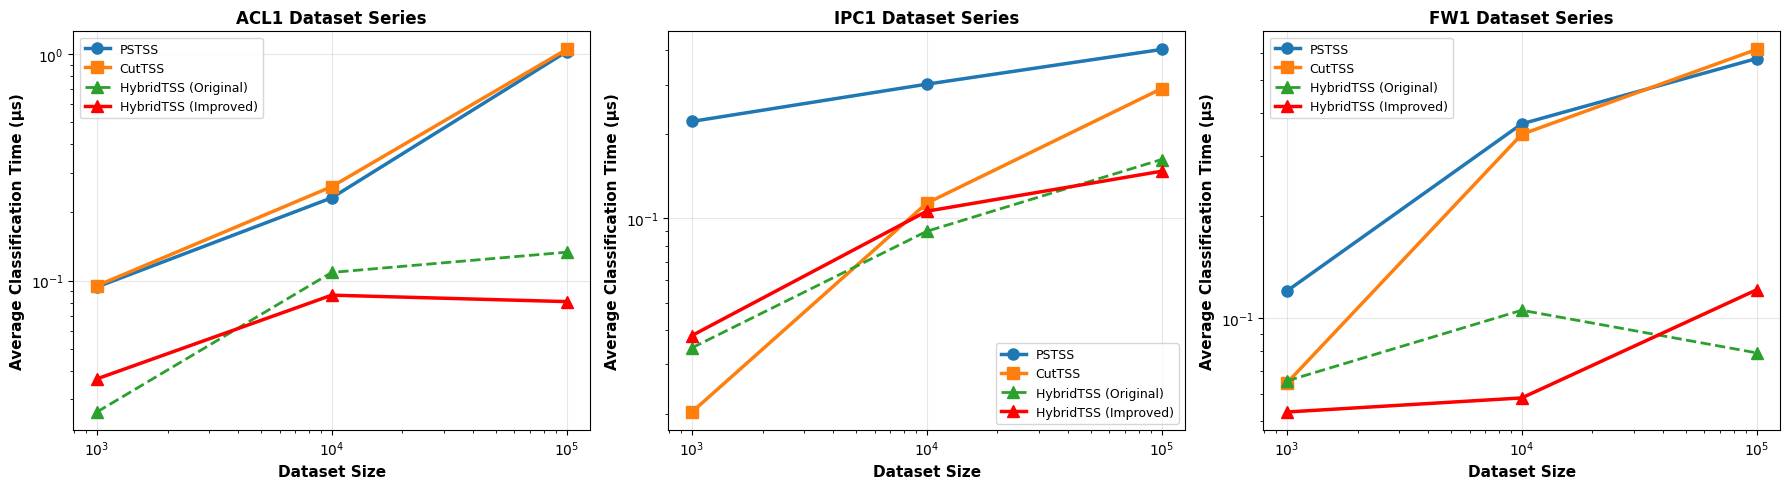


Average Classification Time Comparison (µs):

ACL1 Series:
------------------------------------------------------------------------------------------------------------------------

PSTSS:
  acl1_100k    |     1.0269
  acl1_10k     |     0.2322
  acl1_1k      |     0.0937

CutTSS:
  acl1_100k    |     1.0503
  acl1_10k     |     0.2602
  acl1_1k      |     0.0949

HybridTSS:
  acl1_100k    | Original:     0.1335 | Improved:     0.0808 | Improvement:  39.51%
  acl1_10k     | Original:     0.1087 | Improved:     0.0862 | Improvement:  20.65%
  acl1_1k      | Original:     0.0263 | Improved:     0.0368 | Improvement: -40.09%

IPC1 Series:
------------------------------------------------------------------------------------------------------------------------

PSTSS:
  ipc1_100k    |     0.4032
  ipc1_10k     |     0.3028
  ipc1_1k      |     0.2227

CutTSS:
  ipc1_100k    |     0.2918
  ipc1_10k     |     0.1134
  ipc1_1k      |     0.0203

HybridTSS:
  ipc1_100k    | Original:     0.1626 

In [15]:
plot_metric_comparison('Average_classification_time_us', 'Average Classification Time (µs)', 'Average Classification Time Comparison (µs)')


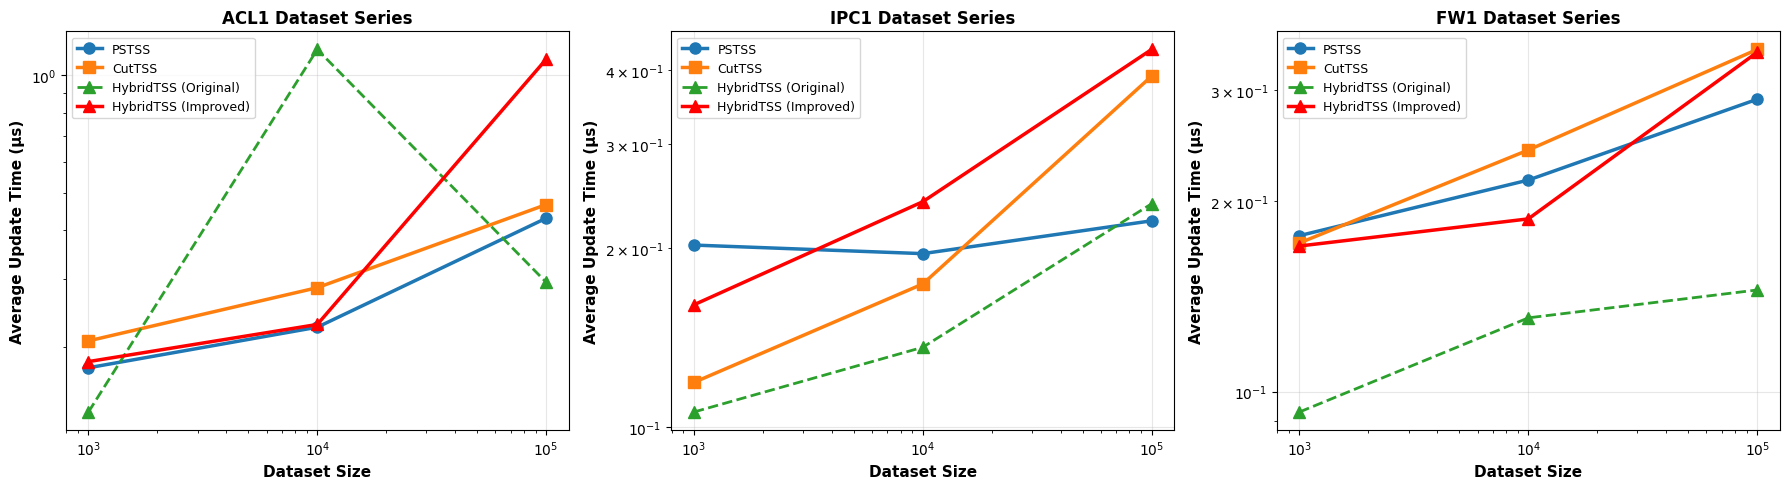


Average Update Time Comparison (µs):

ACL1 Series:
------------------------------------------------------------------------------------------------------------------------

PSTSS:
  acl1_100k    |     0.4296
  acl1_10k     |     0.2254
  acl1_1k      |     0.1773

CutTSS:
  acl1_100k    |     0.4657
  acl1_10k     |     0.2848
  acl1_1k      |     0.2079

HybridTSS:
  acl1_100k    | Original:     0.2942 | Improved:     1.1002 | Improvement: -274.01%
  acl1_10k     | Original:     1.1666 | Improved:     0.2291 | Improvement:  80.36%
  acl1_1k      | Original:     0.1365 | Improved:     0.1839 | Improvement: -34.76%

IPC1 Series:
------------------------------------------------------------------------------------------------------------------------

PSTSS:
  ipc1_100k    |     0.2227
  ipc1_10k     |     0.1960
  ipc1_1k      |     0.2027

CutTSS:
  ipc1_100k    |     0.3903
  ipc1_10k     |     0.1743
  ipc1_1k      |     0.1190

HybridTSS:
  ipc1_100k    | Original:     0.2379 | Impro

In [16]:
plot_metric_comparison('Average_update_time_us', 'Average Update Time (µs)', 'Average Update Time Comparison (µs)')


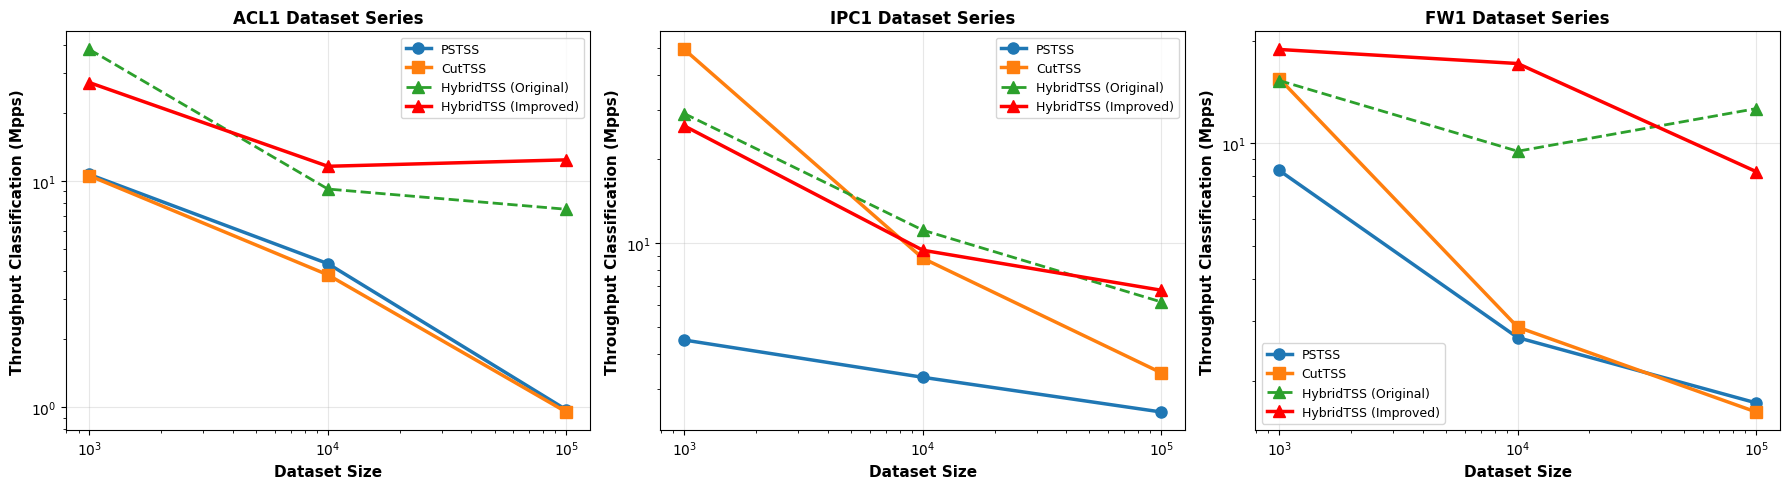


Throughput Classification Comparison (Mpps):

ACL1 Series:
------------------------------------------------------------------------------------------------------------------------

PSTSS:
  acl1_100k    |     0.9738
  acl1_10k     |     4.3072
  acl1_1k      |    10.6724

CutTSS:
  acl1_100k    |     0.9521
  acl1_10k     |     3.8437
  acl1_1k      |    10.5349

HybridTSS:
  acl1_100k    | Original:     7.4899 | Improved:    12.3818 | Improvement: -65.31%
  acl1_10k     | Original:     9.2017 | Improved:    11.5965 | Improvement: -26.03%
  acl1_1k      | Original:    38.0667 | Improved:    27.1728 | Improvement:  28.62%

IPC1 Series:
------------------------------------------------------------------------------------------------------------------------

PSTSS:
  ipc1_100k    |     2.4800
  ipc1_10k     |     3.3023
  ipc1_1k      |     4.4902

CutTSS:
  ipc1_100k    |     3.4271
  ipc1_10k     |     8.8154
  ipc1_1k      |    49.3530

HybridTSS:
  ipc1_100k    | Original:     6.1484 

In [17]:
plot_metric_comparison('Throughput_classification_Mpps', 'Throughput Classification (Mpps)', 'Throughput Classification Comparison (Mpps)')


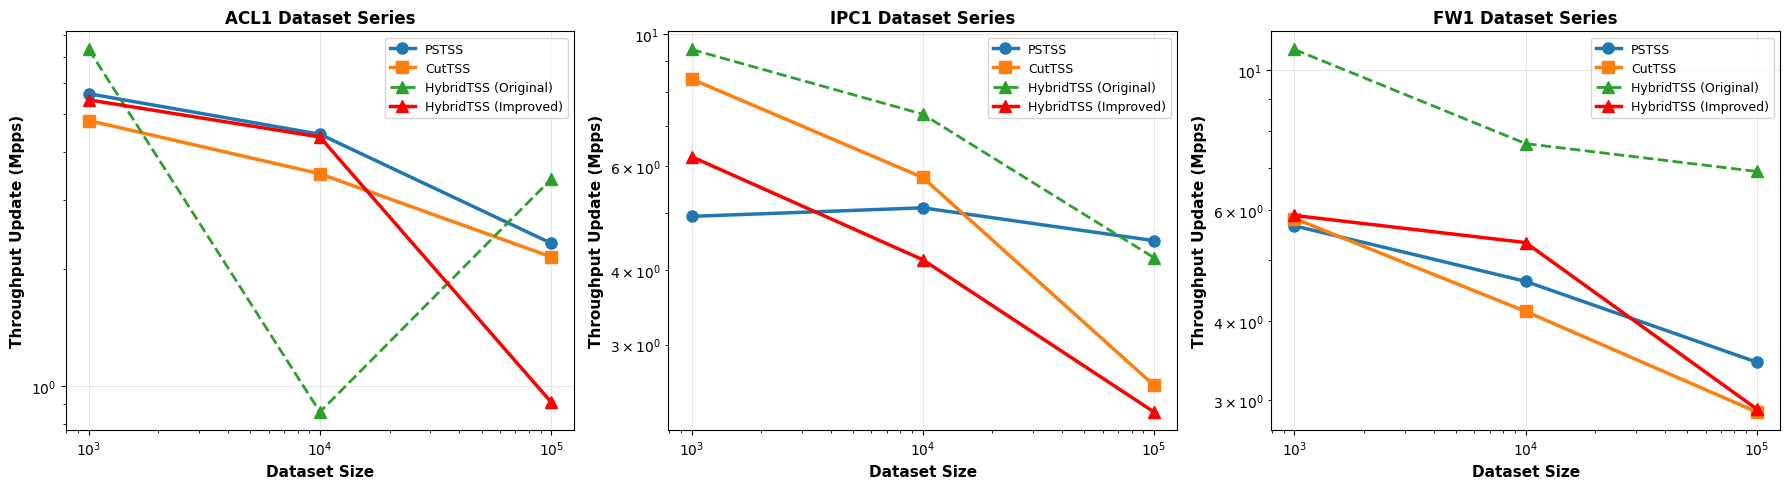


Throughput Update Comparison (Mpps):

ACL1 Series:
------------------------------------------------------------------------------------------------------------------------

PSTSS:
  acl1_100k    |     2.3279
  acl1_10k     |     4.4364
  acl1_1k      |     5.6404

CutTSS:
  acl1_100k    |     2.1473
  acl1_10k     |     3.5109
  acl1_1k      |     4.8107

HybridTSS:
  acl1_100k    | Original:     3.3994 | Improved:     0.9089 | Improvement:  73.26%
  acl1_10k     | Original:     0.8572 | Improved:     4.3650 | Improvement: -409.21%
  acl1_1k      | Original:     7.3281 | Improved:     5.4380 | Improvement:  25.79%

IPC1 Series:
------------------------------------------------------------------------------------------------------------------------

PSTSS:
  ipc1_100k    |     4.4911
  ipc1_10k     |     5.1010
  ipc1_1k      |     4.9343

CutTSS:
  ipc1_100k    |     2.5623
  ipc1_10k     |     5.7379
  ipc1_1k      |     8.4061

HybridTSS:
  ipc1_100k    | Original:     4.2038 | Impro

In [18]:
plot_metric_comparison('Throughput_update_Mpps', 'Throughput Update (Mpps)', 'Throughput Update Comparison (Mpps)')
